### Assignment 9
#### Problem statement:-
Object Recognition using CNN (CIFAR-10 Dataset)
##### a. Train a CNN model to classify CIFAR-10 images into 10 object categories (airplane,cat, car, dog, etc.).
##### b. Use data augmentation to improve model generalization.
##### c. Compare model performance with and without Batch Normalization and Dropout.
## Student Name: Aarti P. Kalyane
## Roll No.: EN231070055
## Batch: B
## Subject: AI&NN

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np


2025-10-10 11:52:00.693104: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1


In [3]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values (0–255) → (0–1)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']


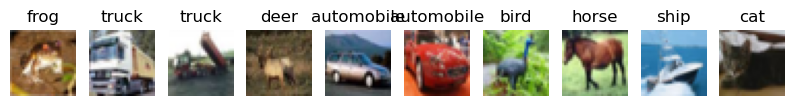

In [5]:
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()


In [7]:
model_simple = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_simple.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

history_simple = model_simple.fit(x_train, y_train, epochs=10, 
                                  validation_data=(x_test, y_test))


2025-10-10 11:52:40.424564: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2025-10-10 11:52:40.425013: W tensorflow/stream_executor/platform/default/dso_loader.cc:60] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2025-10-10 11:52:40.425034: W tensorflow/stream_executor/cuda/cuda_driver.cc:326] failed call to cuInit: UNKNOWN ERROR (303)
2025-10-10 11:52:40.425057: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (mllcomp06): /proc/driver/nvidia/version does not exist
2025-10-10 11:52:40.425614: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild

Epoch 1/10
1562/1563 [============================>.] - ETA: 0s - loss: 1.7638 - accuracy: 0.3451

2025-10-10 11:53:48.622758: W tensorflow/core/framework/cpu_allocator_impl.cc:80] Allocation of 122880000 exceeds 10% of free system memory.


1563/1563 [==============================] - 70s 44ms/step - loss: 1.7635 - accuracy: 0.3453 - val_loss: 1.2485 - val_accuracy: 0.5530
Epoch 2/10
1563/1563 [==============================] - 73s 47ms/step - loss: 1.2150 - accuracy: 0.5670 - val_loss: 1.1834 - val_accuracy: 0.5754
Epoch 3/10
1563/1563 [==============================] - 73s 46ms/step - loss: 1.0452 - accuracy: 0.6337 - val_loss: 1.0620 - val_accuracy: 0.6337
Epoch 4/10
1563/1563 [==============================] - 69s 44ms/step - loss: 0.9333 - accuracy: 0.6720 - val_loss: 0.9503 - val_accuracy: 0.6667
Epoch 5/10
1563/1563 [==============================] - 72s 46ms/step - loss: 0.8670 - accuracy: 0.6961 - val_loss: 0.9915 - val_accuracy: 0.6552
Epoch 6/10
1563/1563 [==============================] - 69s 44ms/step - loss: 0.8102 - accuracy: 0.7148 - val_loss: 0.9152 - val_accuracy: 0.6831
Epoch 7/10
1563/1563 [==============================] - 73s 46ms/step - loss: 0.7509 - accuracy: 0.7368 - val_loss: 0.8617 - val_accura

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)

# CNN with BatchNorm + Dropout
model_bn_do = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_bn_do.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

history_bn_do = model_bn_do.fit(datagen.flow(x_train, y_train, batch_size=64),
                                epochs=20, validation_data=(x_test, y_test))


Epoch 1/20
782/782 [==============================] - ETA: 0s - loss: 2.2823 - accuracy: 0.1195

2025-10-10 12:10:03.490169: W tensorflow/core/framework/cpu_allocator_impl.cc:80] Allocation of 122880000 exceeds 10% of free system memory.


782/782 [==============================] - 332s 423ms/step - loss: 2.2818 - accuracy: 0.1195 - val_loss: 1.5786 - val_accuracy: 0.0447
Epoch 2/20
782/782 [==============================] - 325s 415ms/step - loss: 1.5356 - accuracy: 0.0967 - val_loss: 1.3544 - val_accuracy: 0.1639
Epoch 3/20
782/782 [==============================] - 322s 412ms/step - loss: 1.3870 - accuracy: 0.0929 - val_loss: 1.3639 - val_accuracy: 0.0928
Epoch 4/20
782/782 [==============================] - 332s 424ms/step - loss: 1.2874 - accuracy: 0.0943 - val_loss: 1.0690 - val_accuracy: 0.1193
Epoch 5/20
782/782 [==============================] - 319s 408ms/step - loss: 1.2203 - accuracy: 0.0954 - val_loss: 0.9842 - val_accuracy: 0.1258
Epoch 6/20
782/782 [==============================] - 241s 308ms/step - loss: 1.1556 - accuracy: 0.0967 - val_loss: 0.9421 - val_accuracy: 0.0846
Epoch 7/20
782/782 [==============================] - 209s 267ms/step - loss: 1.1055 - accuracy: 0.0974 - val_loss: 0.8618 - val_accura

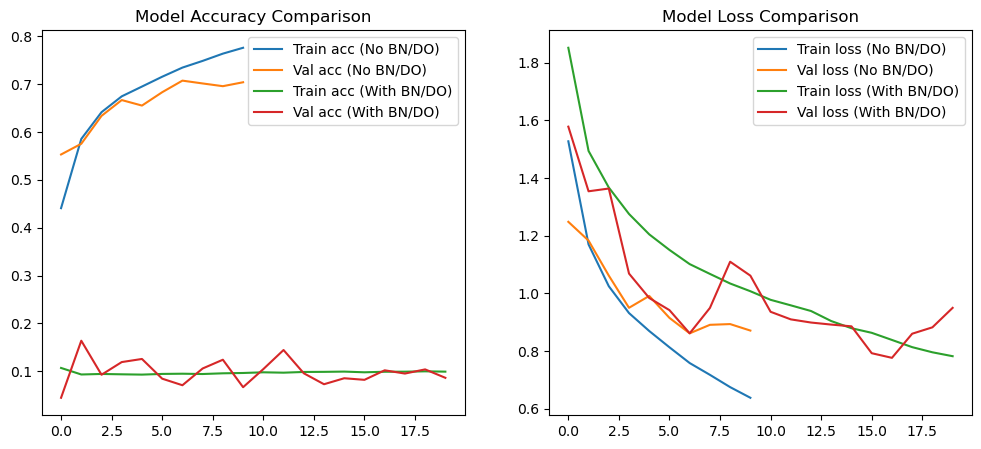

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_simple.history['accuracy'], label='Train acc (No BN/DO)')
plt.plot(history_simple.history['val_accuracy'], label='Val acc (No BN/DO)')
plt.plot(history_bn_do.history['accuracy'], label='Train acc (With BN/DO)')
plt.plot(history_bn_do.history['val_accuracy'], label='Val acc (With BN/DO)')
plt.legend()
plt.title('Model Accuracy Comparison')

plt.subplot(1,2,2)
plt.plot(history_simple.history['loss'], label='Train loss (No BN/DO)')
plt.plot(history_simple.history['val_loss'], label='Val loss (No BN/DO)')
plt.plot(history_bn_do.history['loss'], label='Train loss (With BN/DO)')
plt.plot(history_bn_do.history['val_loss'], label='Val loss (With BN/DO)')
plt.legend()
plt.title('Model Loss Comparison')

plt.show()


In [13]:
test_loss_simple, test_acc_simple = model_simple.evaluate(x_test, y_test, verbose=0)
test_loss_bn_do, test_acc_bn_do = model_bn_do.evaluate(x_test, y_test, verbose=0)

print(f"Without BatchNorm/Dropout - Test Accuracy: {test_acc_simple:.3f}")
print(f"With BatchNorm + Dropout - Test Accuracy: {test_acc_bn_do:.3f}")


2025-10-10 13:21:10.740534: W tensorflow/core/framework/cpu_allocator_impl.cc:80] Allocation of 122880000 exceeds 10% of free system memory.
2025-10-10 13:21:13.673651: W tensorflow/core/framework/cpu_allocator_impl.cc:80] Allocation of 122880000 exceeds 10% of free system memory.


Without BatchNorm/Dropout - Test Accuracy: 0.704
With BatchNorm + Dropout - Test Accuracy: 0.086


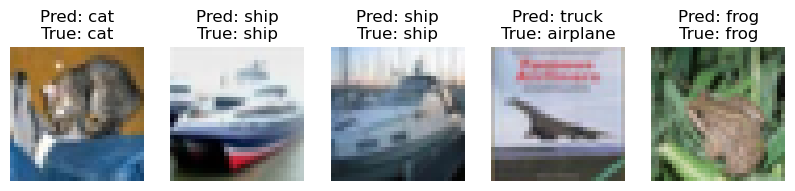

In [15]:
pred = model_bn_do.predict(x_test[:5])
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[i])
    plt.title(f"Pred: {class_names[np.argmax(pred[i])]}\nTrue: {class_names[y_test[i][0]]}")
    plt.axis('off')
plt.show()
